# Detecting Spam Emails Using TensorFlow in Python

In [1]:
# Spam messages are unwanted emails/messages send in bulk to users.
# Detecting spam emails automatically hepls in unnecessary cluter in users' inbox.
# In this model, we built a spam detection model that classifies email as spam or not spam using tensorflow.

## Step 1: Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Step 2: Load a Dataset
we load a dataset containing labelled emails as spam and not spam.

In [3]:
data = pd.read_csv('email.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


We see a glimpse of first 5 rows of the dataset.

In [4]:
data.shape

(5171, 4)

 We also see the shape of the dataset. This dataset contains 5171 rows and 4 columns.
 We will now visualize the label distribution to get understanding of the class distribution

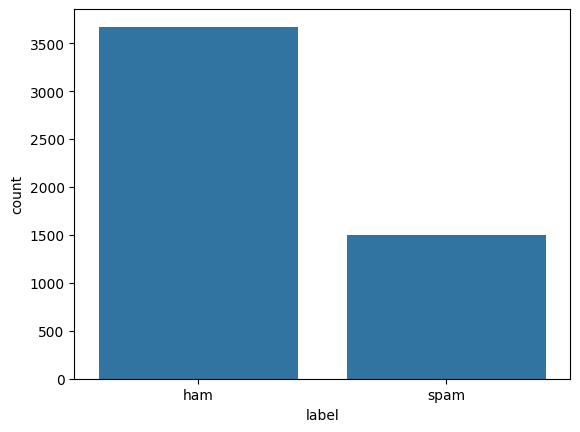

In [5]:
sns.countplot(x='label',data=data)
plt.show()

## Step 3: Balance the Dataset
We can clearly see that number of samples of ham is much more than that of spam, which means we are using an imbalanced dataset. To address the imbalnce we downsample the majority class(ham)to match the minority class (spam).

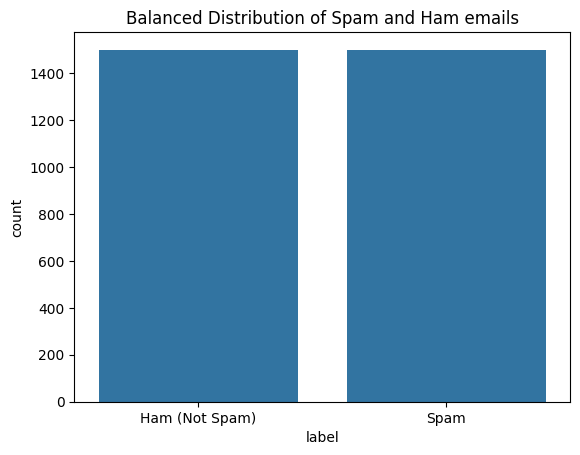

In [6]:
ham_msg = data[data['label']=='ham']
spam_msg = data[data['label']=='spam']

#Downsample Ham emails to match the number of spam emails
ham_msg_balanced =ham_msg.sample(n=len(spam_msg), random_state=42)

#Combined balanced data
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

# Visualize the balanced dataset
sns.countplot(x='label',data=balanced_data)
plt.title("Balanced Distribution of Spam and Ham emails")
plt.xticks(ticks=[0,1],labels=['Ham (Not Spam)','Spam'])
plt.show()

## Step 4: Clean the Text
Textual data often requires preprocessing before feeding it into a machine learning model. Common steps include removing stopwords, punctuations and performing stemming/lemmatization.
We perform the folowing steps:
- removing stopwords,
- removing punctuations,
- performing stemming/lemmatization.

Although removing data means loss of information, we need to do this to make the data  perfectto feed  into a machine learning model.

In [7]:
balanced_data['text']= balanced_data['text'].str.replace('Subject', '')
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [8]:
punctuations_list = string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('','',punctuations_list)
    return text.translate(temp)

balanced_data['text'] = balanced_data['text'].apply(lambda x: remove_punctuations(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


The below function is a helper function that will help us remove stopwords.

In [9]:
def remove_stopwords(text):
    stop_words= stopwords.words('english')

    imp_words = []

    #storing the important words
    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)

    output =" ".join(imp_words)

    return output

balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


## Step 5: Visualization Word Cloud
A word cloud is a text visualization tool that helps us to get insights into the most words present in the corpous of the data.

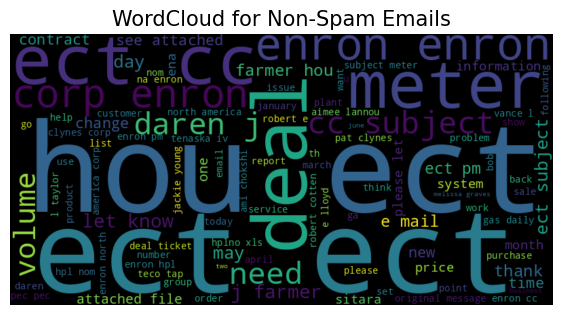

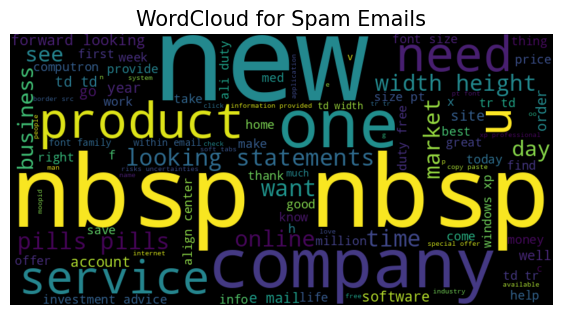

In [10]:
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()
    
plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

## Step 6: Tokenization and Padding
Machine learning models work with numbers so we need to convert the text data into numerical vectors using **Tokenization** and **Padding**.  
Tokenization: Converts each unique word into an integer.  
Padding: Ensures that all text sequence have the same length, making them compatible with the model.

In [11]:
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'],balanced_data['label'], test_size=0.2, random_state=42
)
tokenizer =Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100 # Maximum sequence Length
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

## Step 7: Define the model
We will build a deep learning model using a **sequential** architecture. This model includes:  

- **Embedding Layer**: Learns vector representation of words.  
- **LSTM Layer**: Captures pattern in sequences.  
- **Fully Connected Layer**: Extract relevant values.  
- **Output Layer**: Predicts whether an email is spam or not.

In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(max_len,)),
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 100, 32)             │       1,274,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,278,625 (4.88 MB)

 Trainable params: 1,278,625 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train the Model
We train the model using **EarlyStopping** and **ReduceLROnPlateau** callbacks. These callbacks help stop the training early if the model’s performance doesn’t improve and reduce the learning rate to fine-tune the model.

In [13]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5696 - loss: 0.6818 - val_accuracy: 0.7200 - val_loss: 0.5622 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8653 - loss: 0.3373 - val_accuracy: 0.9467 - val_loss: 0.1958 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9475 - loss: 0.1904 - val_accuracy: 0.9517 - val_loss: 0.1839 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9545 - loss: 0.1713 - val_accuracy: 0.9483 - val_loss: 0.2022 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9562 - loss: 0.1773 - val_accuracy: 0.9667 - val_loss: 0.1483 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9646 - loss: 0.1520 - val_accuracy: 0.9633 - val_loss: 0.1565 - learning_rate: 0.0010
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9662 - loss: 0.1468 - val_acc

After training, we evaluate the model on the test data to measure its performance.

In [14]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9667 - loss: 0.1483
Test Loss : 0.1483113169670105
Test Accuracy : 0.9666666388511658


Thus, the training accuracy turns out to be 97% which is quite satisfactory.

Having trained our model, we can plot a graph depicting the variance of training and validation accuracies with the no. of epochs.

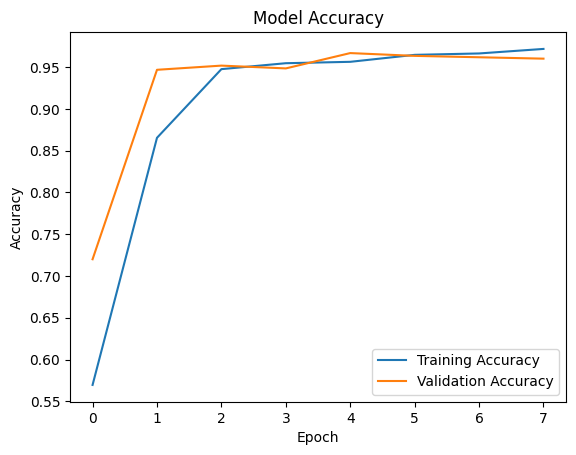

In [15]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

By following these steps, we have successfully built a machine learning model that can classify emails as spam or ham. With further optimization, this model can be fine-tuned to improve its performance even more.